In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import imprl.envs

sns.set_theme(
    context="paper", style="whitegrid", font_scale=1.25, font="Times New Roman"
)

In [2]:
# Setup for this figure:
# - Load the summary/eval CSVs.
# - Define the 4 hard-k settings used below.
# - Get SARSOP baselines for normalization.
# - Load EPyMARL results from ./data/kn_infinite_results_epymarl.csv.
# - Merge local runs + EPyMARL runs into one plotting dataframe.

# Primary result tables
results_summary_df = pd.read_csv("./data/results_summary.csv")
results_evals_df = pd.read_csv("./data/results_evals.csv")

ENV_NAME = "k_out_of_n_infinite"
SETTINGS = [f"hard-{k}-of-4_infinite" for k in range(1, 5)]
SETTING_NAMES = [f"{k}-out-of-4" for k in range(1, 5)]

ALGORITHMS = results_summary_df["algorithm"].unique().tolist()
ALGORITHM_NAMES = [alg.replace("_", "-").upper() for alg in ALGORITHMS]

# Baselines per setting
BASELINES = {}
for setting in SETTINGS:
    env = imprl.envs.make(ENV_NAME, setting)
    BASELINES[setting] = env.core.baselines

# EPyMARL comparison table
# Generated by: python results/extract_epymarl_results.py
epymarl_df = pd.read_csv("./data/kn_infinite_results_epymarl.csv")

# Quick integrity check: runs available per (setting, algorithm)
display(epymarl_df.groupby(["setting", "algorithm"]).size().unstack(fill_value=0))

# Keep only methods/settings relevant to this figure from the local summary table
results_summary_filtered = results_summary_df[
    results_summary_df["algorithm"].isin(ALGORITHMS)
    & results_summary_df["setting"].isin(SETTINGS)
].copy()

# Combine local methods + EPyMARL variants into one table for plotting
combined_df = pd.concat(
    [
        results_summary_filtered[
            results_summary_filtered["algorithm"].isin(["DDQN", "MAPPO_PS", "IPPO_PS", "QMIX_PS"])
        ],
        epymarl_df,
    ],
    ignore_index=True,
)

# Plot order for grouped box/strip plots
combined_df["algorithm"] = pd.Categorical(
    combined_df["algorithm"],
    categories=[
        "DDQN",
        "MAPPO_PS",
        "mappo-EPyMARL",
        "QMIX_PS",
        "qmix-EPyMARL",
        "IPPO_PS",
        "ippo-EPyMARL",
    ],
    ordered=True,
)

algorithm,ippo-EPyMARL,mappo-EPyMARL,qmix-EPyMARL
setting,,,
hard-1-of-4_infinite,10,10,10
hard-2-of-4_infinite,10,10,10
hard-3-of-4_infinite,10,10,10
hard-4-of-4_infinite,9,9,10


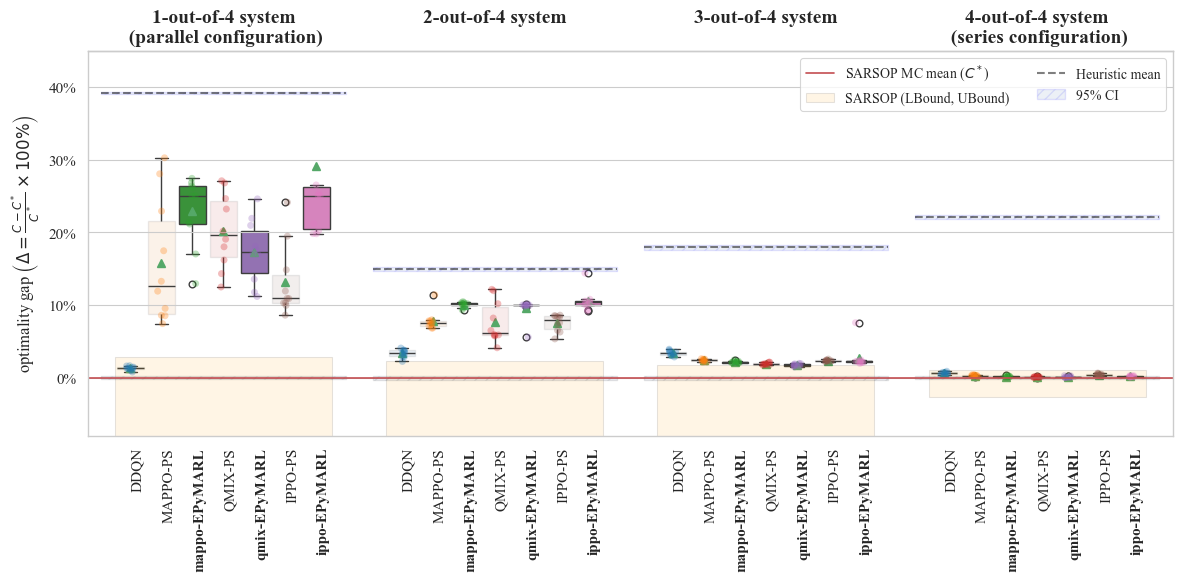

In [3]:
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(14, 5))
ax.grid(axis="x", linestyle="-", alpha=0.1)

sns.boxplot(
    combined_df,
    ax=ax,
    x="setting",
    y="normalized_best_cost",
    hue="algorithm",
    palette="tab10",
    showmeans=True,
    linewidth=1,
    width=0.8,
    gap=0.15,
    zorder=0,
    legend=False,
    boxprops=dict(alpha=0.9),
)

sns.stripplot(
    combined_df,
    ax=ax,
    x="setting",
    y="normalized_best_cost",
    hue="algorithm",
    palette="tab10",
    dodge=True,
    alpha=0.3,
    jitter=0.1,
    zorder=2,
    legend=False,
)

# Seaborn draws boxes grouped by x then hue — order matters
all_patches = [p for p in ax.patches if isinstance(p, matplotlib.patches.PathPatch)]
_positions = []

for patch in all_patches:
    path = patch.get_path()
    vertices = path.vertices
    # The x coordinates of the box are in vertices[:, 0]
    # Take mean of left and right x coordinates
    box_x = vertices[0:2, 0].mean()
    _positions.append(box_x)
_positions = sorted(_positions)

_labels = [
    [
        "DDQN",
        "MAPPO-PS",
        "mappo-EPyMARL",
        "QMIX-PS",
        "qmix-EPyMARL",
        "IPPO-PS",
        "ippo-EPyMARL",
    ]
    * len(SETTINGS)
][0]
ax.set_xticks(_positions)
ax.set_xticklabels(_labels, rotation=90, ha="left")
# Bold the entire label for EPyMARL entries
for _tick in ax.get_xticklabels():
    if "EPyMARL" in _tick.get_text():
        _tick.set_fontweight("bold")
ax.set_xlabel(None)

# Get tick positions and their corresponding labels
tick_positions = ax.get_xticks()
tick_labels = [t.get_text() for t in ax.get_xticklabels()]
# Matplotlib transform from display to data
inv = ax.transData.inverted()

for patch in all_patches:
    # Get center in display coordinates
    bbox = patch.get_extents()
    center_display = [(bbox.x0 + bbox.x1) / 2, (bbox.y0 + bbox.y1) / 2]

    # Convert to data coordinates
    center_data = inv.transform(center_display)
    x_center = center_data[0]  # compare to xticks in data units

    # Find nearest tick
    distances = [abs(x_center - x) for x in tick_positions]
    closest_tick_idx = distances.index(min(distances))
    label = tick_labels[closest_tick_idx]

    # Set transparency
    if "EPyMARL" in label:
        patch.set_alpha(1)
    else:
        patch.set_alpha(0.1)

# plot horizontal line for SARSOP
ax.axhline(y=0, color="r", linestyle="-", label=r"SARSOP MC mean ($C^*$)")

ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.08, 0.45)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel(
    r"optimality gap $\left( \Delta = \frac{C - C^*}{C^*} \times 100\% \right)$",
    fontsize=12,
)

for s in range(len(SETTINGS)):

    # LBound and UBound for SARSOP
    _sarsop = BASELINES[SETTINGS[s]]["SARSOP"]
    baseline = _sarsop["mean"]
    LBound, UBound = _sarsop["LBound"], _sarsop["UBound"]
    rel_LBound = LBound / baseline - 1
    rel_UBound = UBound / baseline - 1

    ax.fill_between(
        [s - 0.4, s + 0.4],
        rel_LBound,
        rel_UBound,
        color="orange",
        alpha=0.1,
        edgecolor="black",
        label="SARSOP (LBound, UBound)",
    )

    # mean and 95% CI from Monte Carlo rollout
    MC_mean, MC_95_ci = _sarsop["mean"], _sarsop["95_ci"]
    MC_lower = MC_95_ci[0] / baseline - 1
    MC_upper = MC_95_ci[1] / baseline - 1

    ax.fill_between(
        [s - 0.45, s + 0.45],
        MC_lower,
        MC_upper,
        color=None,
        alpha=0.1,
        edgecolor="black",
        hatch="///",
        linewidth=1,
        # label="SARSOP Monte Carlo 95% CI",
    )

    # Inspect Replacement Heuristic
    _heuristic = BASELINES[SETTINGS[s]]["InspectRepair"]
    MC_mean, MC_95_ci = _heuristic["mean"], _heuristic["95_ci"]
    MC_lower = MC_95_ci[0] / baseline - 1
    MC_upper = MC_95_ci[1] / baseline - 1

    ax.hlines(
        y=MC_mean / baseline - 1,
        xmin=s - 0.45,
        xmax=s + 0.45,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        label="Heuristic mean",
    )
    ax.fill_between(
        [s - 0.45, s + 0.45],
        MC_lower,
        MC_upper,
        color=None,
        alpha=0.1,
        edgecolor="blue",
        hatch="///",
        linewidth=1,
        label="95% CI",
    )

# Create a secondary x-axis for settings
secax = ax.secondary_xaxis("top")
secax.set_xticks(np.arange(len(SETTINGS)))
_names = [
    "1-out-of-4 system\n (parallel configuration)",
    "2-out-of-4 system\n ",
    "3-out-of-4 system\n ",
    "4-out-of-4 system\n (series configuration)",
]
secax.set_xticklabels(_names, fontsize=14, fontdict={"weight": "bold"})
secax.tick_params(axis="x", which="both", length=0)

# Get auto-generated legend handles and labels
auto_handles, auto_labels = ax.get_legend_handles_labels()
# Remove duplicates while maintaining order
unique_legend = dict(zip(auto_labels, auto_handles))
plt.legend(
    unique_legend.values(),
    unique_legend.keys(),
    loc="upper right",
    fontsize=10,
    ncols=2,
)

fig_name = "epymarl_validation"
plt.savefig(f"./figures/{fig_name}.pdf", bbox_inches="tight", transparent=True)

plt.show()